<a href="https://colab.research.google.com/github/twillixa/Algorithm-in-BI/blob/main/Main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
!pip install odfpy -q
!git clone https://github.com/twillixa/Algorithm-in-BI.git
%cd Algorithm-in-BI
import pandas as pd
import matplotlib.pyplot as plt

Cloning into 'Algorithm-in-BI'...
remote: Enumerating objects: 34, done.
remote: Counting objects: 100% (34/34), done.
remote: Compressing objects: 100% (31/31), done.
remote: Total 34 (delta 8), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (34/34), 919.86 KiB | 7.48 MiB/s, done.
Resolving deltas: 100% (8/8), done.
/content/Algorithm-in-BI/Algorithm-in-BI/Algorithm-in-BI


##Loading

In [8]:


clients  = pd.read_excel("RawData/clients.ods",  engine="odf")
comandes = pd.read_excel("RawData/comandes.ods", engine="odf")
commandes_details = pd.read_excel("RawData/commandes details.ods", engine="odf")

clients.to_csv("RawData/clients.csv",   index=False, encoding="utf-8-sig")
comandes.to_csv("RawData/comandes.csv", index=False, encoding="utf-8-sig")

print(f"clients  → {clients.shape}")
print(f"comandes → {comandes.shape}")

clients  → (1537, 5)
comandes → (2039, 11)


##Cleaning

In [13]:
# 1. Drop unnecessary columns
comandes.drop(columns=["NOM", "EMAIL", "DEVISE"], inplace=True, errors="ignore")

# 2a. Parse DATE COMMANDE as datetime
comandes["DATE COMMANDE"] = pd.to_datetime(comandes["DATE COMMANDE"])

# 2b. Standardize ANNEE DE NAISSANCE → extract year as integer
comandes["ANNEE DE NAISSANCE"] = (
    comandes["ANNEE DE NAISSANCE"]
    .astype(str)
    .str.extract(r"(\d{4})")
    .astype("Int64")
)

# 3. Cast CODE POSTAL to string
comandes["CODE POSTAL"] = (
    comandes["CODE POSTAL"]
    .astype(str)
    .str.strip()
    .replace("nan", pd.NA)
)

# 4. Flag & drop duplicate CODE COMMANDE
comandes["IS_DUPLICATE"] = comandes.duplicated(subset="CODE COMMANDE", keep=False)
print(f"Duplicate orders flagged: {comandes['IS_DUPLICATE'].sum()}")
comandes = comandes[comandes["IS_DUPLICATE"] == False].drop(columns=["IS_DUPLICATE"])

# 5. Categorical variable for MODE DE PAIEMENT
comandes["MODE DE PAIEMENT"] = pd.Categorical(comandes["MODE DE PAIEMENT"])
print("Payment categories:", comandes["MODE DE PAIEMENT"].cat.categories.tolist())

# 6. Compute age
comandes["AGE"] = 2026 - comandes["ANNEE DE NAISSANCE"]

print(comandes.dtypes)
display(comandes.head())



# 1. Drop unnecessary columns
clients.drop(columns=["NOM", "EMAIL"], inplace=True, errors="ignore")

# 2. Standardize ANNÉE DE NAISSANCE → extract year as integer
clients["ANNÉE DE NAISSANCE"] = (
    clients["ANNÉE DE NAISSANCE"]
    .astype(str)
    .str.extract(r"(\d{4})")
    .astype("Int64")
)

# 3. Compute age
clients["AGE"] = 2026 - clients["ANNÉE DE NAISSANCE"]

display(clients.head())

Duplicate orders flagged: 0
Payment categories: ['Caisse - Carte de crédit', 'Carte de crédit', 'Gratuit', 'Postcard', 'Twint']
PRENOM                        object
CODE COMMANDE                  int64
DATE COMMANDE         datetime64[ns]
MONTANT                        int64
MODE DE PAIEMENT            category
NB BILLETS                     int64
CODE POSTAL                   object
ANNEE DE NAISSANCE             Int64
AGE                            Int64
dtype: object


,PRENOM,CODE COMMANDE,DATE COMMANDE,MONTANT,MODE DE PAIEMENT,NB BILLETS,CODE POSTAL,ANNEE DE NAISSANCE,AGE
0,fiona,69863303,2025-12-16 13:55:55,142,Carte de crédit,3,<NA>,1972,54
1,Natascha,69865565,2025-12-16 16:19:31,93,Twint,2,1023,1964,62
2,Martine,69866924,2025-12-16 17:28:10,44,Twint,1,1510,1964,62
3,Pierre-Philippe,69866513,2025-12-16 17:32:24,88,Carte de crédit,2,1033,1955,71
4,Sandra,69869702,2025-12-16 19:57:18,49,Twint,1,1022,1976,50


,PRENOM,CODE POSTAL,ANNÉE DE NAISSANCE,AGE
0,Abel,1003,1994,32
1,Adam,1022,1999,27
2,Adam,2740,2003,23
3,Adela,1007,1976,50
4,Adèle,1040,2003,23


In [14]:



# Merge on order number — ticket level
merged = commandes_details.merge(
    comandes,
    left_on="order number",
    right_on="CODE COMMANDE",
    how="left"
)

# Drop duplicate and irrelevant columns
merged.drop(columns=[
    # Duplicates (keeping comandes versions)
    "payment mode", "Customer", "Customer Firstname",
    # Irrelevant
    "order status", "memo", "Barcode", "Barcode Datas", "Type",
    "Seat", "Row", "Block", "Email", "Zone","EMAIL",
    "Customer Lastname","NOM","DEVISE",
    "promo","Seller Firstname","Seller Lastname",
    "Customer Language", "comment", "Pass email",
    "Pass Firstname", "Pass Lastname", "Pass Email",
    # Clean up merge key duplicate
    "CODE COMMANDE"
], inplace=True, errors="ignore")

print(f"merged → {merged.shape}")
print(merged.dtypes)
display(merged.head())

merged → (8578, 17)
event name                       object
event date                       object
Booking date                     object
order number                      int64
status                           object
Amount                            int64
Amount avec promotion             int64
Event date                       object
Tariff                           object
PRENOM                           object
DATE COMMANDE            datetime64[ns]
MONTANT                         float64
MODE DE PAIEMENT               category
NB BILLETS                      float64
CODE POSTAL                      object
ANNEE DE NAISSANCE                Int64
AGE                               Int64
dtype: object


,event name,event date,Booking date,order number,status,Amount,Amount avec promotion,Event date,Tariff,PRENOM,DATE COMMANDE,MONTANT,MODE DE PAIEMENT,NB BILLETS,CODE POSTAL,ANNEE DE NAISSANCE,AGE
0,Another Kind Of Magic – A vocal tribute to Queen,2026-03-06 20:00:00,2025-12-16 13:55:55,69863303,Billet scanné,49,49,2026-03-06 19:35:43,Tarif plein,fiona,2025-12-16 13:55:55,142.0,Carte de crédit,3.0,<NA>,1972,54
1,Another Kind Of Magic – A vocal tribute to Queen,2026-03-06 20:00:00,2025-12-16 13:55:55,69863303,Billet valide,49,49,NaN,Tarif plein,fiona,2025-12-16 13:55:55,142.0,Carte de crédit,3.0,<NA>,1972,54
2,Another Kind Of Magic – A vocal tribute to Queen,2026-03-06 20:00:00,2025-12-16 13:55:55,69863303,Billet scanné,44,44,2026-03-06 19:39:38,Tarif réduit,fiona,2025-12-16 13:55:55,142.0,Carte de crédit,3.0,<NA>,1972,54
3,Another Kind Of Magic – A vocal tribute to Queen,2026-03-06 20:00:00,2025-12-16 16:19:31,69865565,Billet scanné,49,49,2026-03-06 19:36:16,Tarif plein,Natascha,2025-12-16 16:19:31,93.0,Twint,2.0,1023,1964,62
4,Another Kind Of Magic – A vocal tribute to Queen,2026-03-06 20:00:00,2025-12-16 16:19:31,69865565,Billet scanné,44,44,2026-03-06 19:36:23,Tarif réduit,Natascha,2025-12-16 16:19:31,93.0,Twint,2.0,1023,1964,62


In [16]:
print(merged.isnull().sum())
print(f"\nTotal rows: {len(merged)}")


event name                  0
event date                  0
Booking date                0
order number                0
status                      0
Amount                      0
Amount avec promotion       0
Event date               4498
Tariff                      0
PRENOM                   3040
DATE COMMANDE            3017
MONTANT                  3017
MODE DE PAIEMENT         3017
NB BILLETS               3017
CODE POSTAL              3284
ANNEE DE NAISSANCE       3166
AGE                      3166
dtype: int64

Total rows: 8578


##Graph

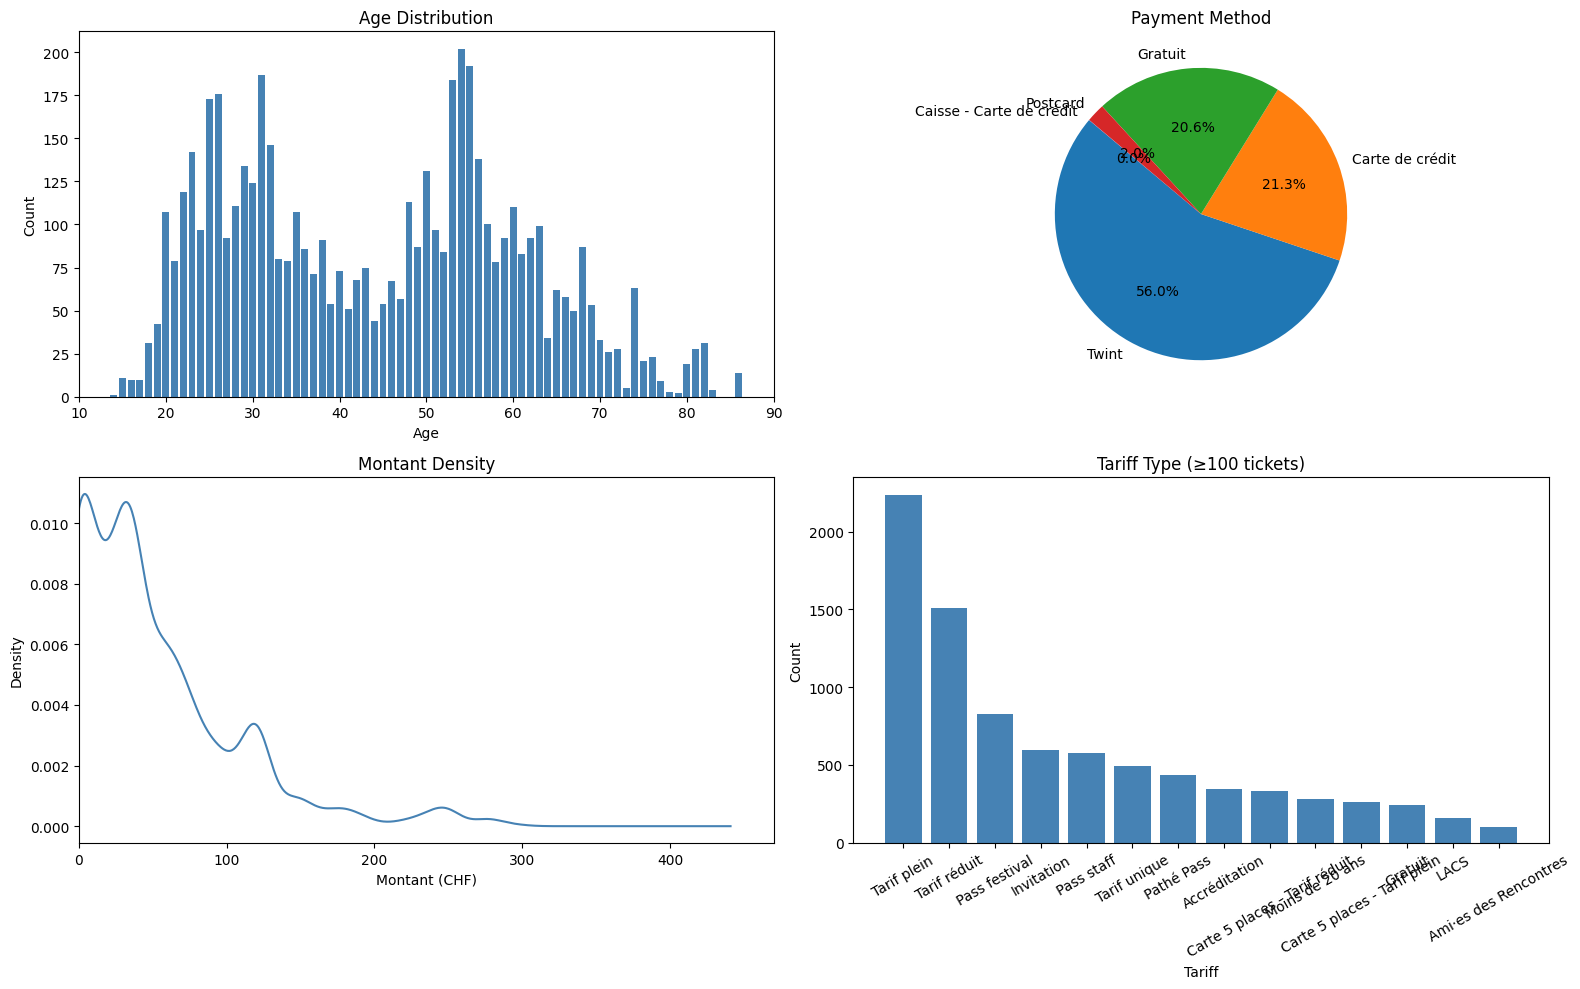

In [20]:

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Age distribution — cap to valid range
age_data = merged["AGE"].dropna()
age_data = age_data[(age_data >= 0) & (age_data <= 120)]
age_counts = age_data.value_counts().sort_index()
axes[0, 0].bar(age_counts.index, age_counts.values, color="steelblue")
axes[0, 0].set_title("Age Distribution")
axes[0, 0].set_xlabel("Age")
axes[0, 0].set_ylabel("Count")

# 2. Pie chart — Payment method
payment_counts = merged["MODE DE PAIEMENT"].dropna().value_counts()
axes[0, 1].pie(payment_counts.values, labels=payment_counts.index, autopct="%1.1f%%", startangle=140)
axes[0, 1].set_title("Payment Method")

# 3. Density plot — Montant, starting at 0
montant_data = merged["MONTANT"].dropna()
montant_data = montant_data[montant_data >= 0]
montant_data.plot.kde(ax=axes[1, 0], color="steelblue")
axes[1, 0].set_xlim(left=0)
axes[1, 0].set_title("Montant Density")
axes[1, 0].set_xlabel("Montant (CHF)")

# 4. Tariff type — exclude categories with less than 100 tickets
tariff_counts = merged["Tariff"].dropna().value_counts()
tariff_counts = tariff_counts[tariff_counts >= 100]
axes[1, 1].bar(tariff_counts.index, tariff_counts.values, color="steelblue")
axes[1, 1].set_title("Tariff Type (≥100 tickets)")
axes[1, 1].set_xlabel("Tariff")
axes[1, 1].set_ylabel("Count")
axes[1, 1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()